[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lshofsl/Advanced-topics-in-PoD-project-/blob/main/EBM_NCA.ipynb)


In [2]:
# Baseline NCA adapted
# @misc{guichard2025engramncaneuralcellularautomaton,
     # title={EngramNCA: a Neural Cellular Automaton Model of Memory Transfer},
     # author={Etienne Guichard and Felix Reimers and Mia Kvalsund and Mikkel Lepperød and Stefano Nichele},
     # year={2025},
     # eprint={2504.11855},
     # archivePrefix={arXiv},
     # primaryClass={cs.NE},
     # url={https://arxiv.org/abs/2504.11855},
#}


import os
import sys

!rm -rf Advanced-topics-in-PoD-project-
!git clone https://github.com/lshofsl/Advanced-topics-in-PoD-project-.git

repo_path = os.path.abspath("Advanced-topics-in-PoD-project-")
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

if os.path.exists(repo_path):
    print("Success! Files now found:", os.listdir(repo_path))

Cloning into 'Advanced-topics-in-PoD-project-'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 87 (delta 34), reused 48 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 1.50 MiB | 1.53 MiB/s, done.
Resolving deltas: 100% (34/34), done.
Success! Files now found: ['Images', 'NCA_baseline.py', 'NCA.py', '.git', 'README.md', 'EBM_NCA.ipynb', 'EBM_NCA_baseline.ipynb', 'utils.py']


In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from NCA import *
import utils as utils
from IPython.display import Image, HTML, clear_output
import torch.nn.functional as F
import logging
from IPython.display import display, HTML, Video
from PIL import Image
import cv2
from base64 import b64encode
logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)


Using device: cuda


In [4]:

#@title Setup { vertical-output: true}
HEIGHT = 30 #@param {type:"integer"}
WIDTH = 30 #@param {type:"integer"}
CHANNELS = 16 # @param {type:"integer"}<--- NCA feature channels
BATCH_SIZE = 12 #@param {type:"integer"}
PADDING = 5 #@param {type:"integer"}
GENE_COUNT = 3 #@param {type:"integer"} <-- Number of gene channels to use for "private" information
POOL_SIZE = 2666 #@param {type:"integer"}<--- NCA training pool size, lower values train faster but are less stable
TRAINING_ITERS = 8000  #@param {type:"integer"}<-- Number of trainign iterations
HIDDEN_SIZE = 64 #@param {type:"integer"}<--- NCA hidden size
PRIMITIVES_SHAPES = ["Images/square.png", "Images/circle.png", "Images/triangle.png"]
PRIMITIVES_BODY_PARTS = ["Images/Torso.png", "Images/Head.png", "Images/Tail.png", "Images/leg1.png", "Images/leg2.png", "Images/leg3.png", 'Images/leg4.png']
PRIMITIVES_LINES = ["Images/horizontal.png", "Images/Verical.png"]
style = """
<style>
.output_wrapper, .output {
    display: flex;
    flex-direction: row-reverse; /* Align content to the right */
}
</style>
"""


In [7]:
paths = [os.path.join(repo_path, p) for p in PRIMITIVES_SHAPES]

images = []
images_to_display = []
for path in paths:
    # utils.get_image calls cv2.imread which needs the correct absolute path.
    image, image_to_display = utils.get_image(path, HEIGHT, WIDTH, padding=PADDING)
    images.append(image)
    images_to_display.append(image_to_display)

genes = [[0], [1], [2]] # <-- Gene one hot encoding, indicates which bits if the gene sequence for each encoded "image" should be 1, [0] = 001, [0,1] = 011, [2] = 100 etc. for 3 bits genes. One, one-hot encoding per image, this rule applies for any gene size

HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING
assert len(paths) == len(genes), 'Genes and images should have the same length '

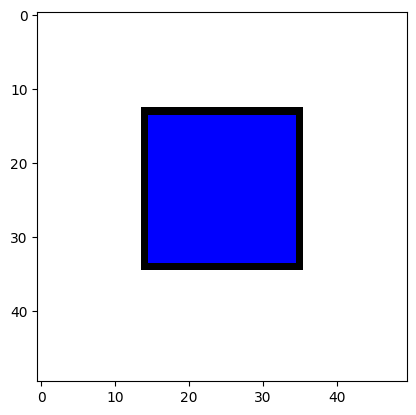

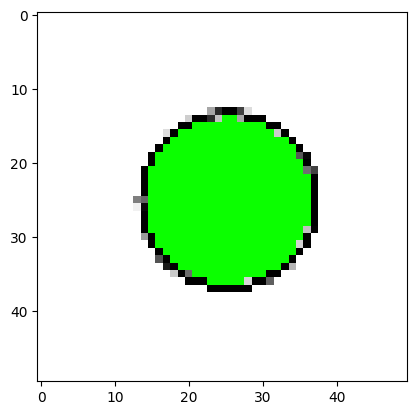

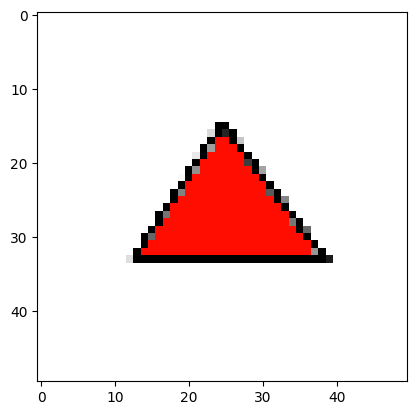

In [8]:
#@title Display Primitives { vertical-output: true}
for i,image in enumerate(images_to_display):
    plt.figure(3+i)
    plt.imshow(image)
pools = []
for gene in genes:
    pools.append(utils.make_gene_pool(gene, pool_size=POOL_SIZE,height=HEIGHT, width=WIDTH, channels=CHANNELS, gene_size=GENE_COUNT, device=DEVICE))
seeds = []
for pool in pools:
    seeds.append(pool[0].clone())

In [9]:
partitions = len(paths)
if partitions == 1:
    part = [BATCH_SIZE]
div = BATCH_SIZE//partitions
rem = BATCH_SIZE % partitions
part = [div + 1 if i < rem else div for i in range(partitions)]
print(f"Batch image paritions = {part}. Batch Size of {BATCH_SIZE}. Number of Partitions = {partitions}")

Batch image paritions = [4, 4, 4]. Batch Size of 12. Number of Partitions = 3


In [10]:

sobel_x = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], dtype=torch.float32, device=DEVICE)
lap = torch.tensor([[1.0, 2.0, 1.0], [2.0, -12, 2.0], [1.0, 2.0, 1.0]], dtype=torch.float32, device=DEVICE)
filters = torch.stack([sobel_x, sobel_x.T, lap])
folder = "Gene"

In [11]:
path = "Trained_models/" + folder
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Path: {path} created")
else:
    print(f"Path: {path} already exists, all OK!")


Path: Trained_models/Gene created


In [12]:
#@title Initialise NCA { vertical-output: true}
bases = [images[i].tile(part[i],1,1,1) for i in range(len(part))]
base = torch.cat(bases, dim =0 ).to(DEVICE)
loss_log = []
nca = GeneCA(CHANNELS,HIDDEN_SIZE, gene_size=GENE_COUNT)
nca = nca.to(DEVICE)
optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=2000, gamma=0.3)
name = folder + "/" +type(nca).__name__ + "_gene_size_" +str(GENE_COUNT)

To integrate an energy-gradient foundation into our framework, we modify the forward pass of the NCA by incorporating a static Hopfield-style energy function:
$$E = \frac{1}{2}||s||^2$$
Where the energy gradient with respect s is
$$\Delta_s E = -s$$


By incorporating this into our cellular automaton update rule, we introduce a positive feedback mechanism. Active states with positive values are driven to become more positive, while negative states become more negative, forcefully pushing the cellular state away from zero and making the dynamics energy-driven.

During training, the loss function is extended with a scalar energy
regularization term. This ensures that the optimization accounts not
only for morphological reconstruction but also for the energy profile
of the generated state:

$$\mathcal{L} = \mathcal{L}_{\text{morphology}} + \alpha \cdot E(s_t)$$

where $s_t$ is the current cell state and $\alpha$ is a regularization
hyperparameter. The morphology loss is the pixelwise MSE over the
visible channels:

$$\mathcal{L}_{\text{morphology}} = \frac{1}{H \times W \times C}
\| s_t[0:4] - \hat{s}[0:4] \|^2$$

where $\hat{s}$ denotes the target image and the index $[0:4]$
selects the visible RGBA channels.

In [13]:
#@title Training { vertical-output: true}
energy = []

for i in range(TRAINING_ITERS + 1):
    loss = 0
    with torch.no_grad():
        idxs, x = utils.get_gene_pool(pools, part, seeds)

    for _ in range( random.randrange(32,92)):
        x = nca(x)

    loss_base = (base - x[:, :4, :, :]).pow(2).sum() + 0.1 *(perchannel_conv(base, filters) - perchannel_conv(x[:, :4, :, :], filters) ).pow(2).sum()
    ## We add an energy constrain on the loss
    energy_target = -0.5 * torch.sum(base.pow(2))  ##Energy of the target
    energy_nca_state = -0.5 * torch.sum(x[:, :4, :, :].pow(2))
    energy.append(energy_nca_state.item())
    ## Total loss of the energy targets
    loss_energy = (energy_target - energy_nca_state).pow(2)

    gamma = 0.01  ## Hyperparameter
    loss = loss_base + gamma * loss_energy


    with torch.no_grad():
        loss.backward()
        for p in nca.parameters():
            p.grad /= (p.grad.norm() + 1e-8)
        optim.step()

        x = x.detach()
        optim.zero_grad()

    loss_log.append(loss.log().item())
    with torch.no_grad():
        pools = utils.udate_gene_pool(pools, x.clone().detach(), idxs, part)
    scheduler.step()

    if i % 100 == 0:
        print(f"Training itter {i}, loss = {loss.item()}")
        plt.clf()
        clear_output()
        plt.figure(1,figsize=(10, 4))
        plt.title('Loss history')
        plt.plot(loss_log, '.', alpha=0.5, color = "b")
        print("Batch")
        utils.show_batch(x[2:14])
        display(HTML(style))
        plt.show(block=False)
        plt.pause(0.01)
    if i % 100 == 0:
        torch.save(nca.state_dict(), "Trained_models/" + name + ".pth")
        print("Trained_models/" + name + ".pth")



NameError: name 'beta' is not defined

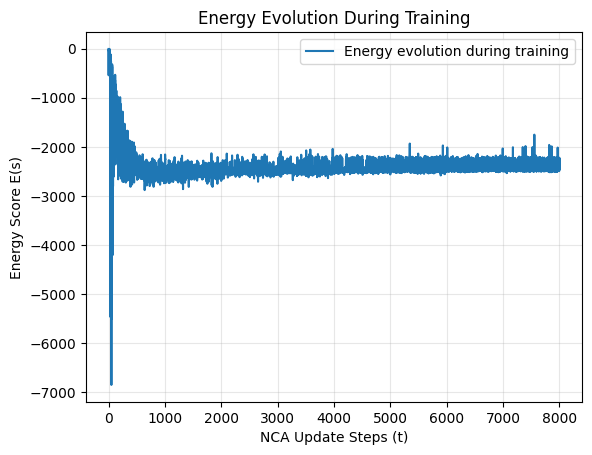

In [ ]:
plt.plot(range(TRAINING_ITERS + 1), energy, label="Energy evolution during training")
plt.xlabel("NCA Update Steps (t)")
plt.ylabel("Energy Score E(s)")
plt.title("Energy Evolution During Training")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
nca = GeneCA(CHANNELS,hidden_n=HIDDEN_SIZE, gene_size=GENE_COUNT)
nca.load_state_dict(torch.load("Trained_models/Gene/GeneCA_gene_size_3.pth"))
nca.to(DEVICE).eval()

GeneCA(
  (w1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(64, 7, kernel_size=(1, 1), stride=(1, 1), bias=False)
)

Now we can test the model, first we analyse how good is to grow a morphology and mantain the shape. Therefore we can analyse the energy function during the training and observed if it reach a minimun, as we are storing 3 shapes, we should observe 3 valleys

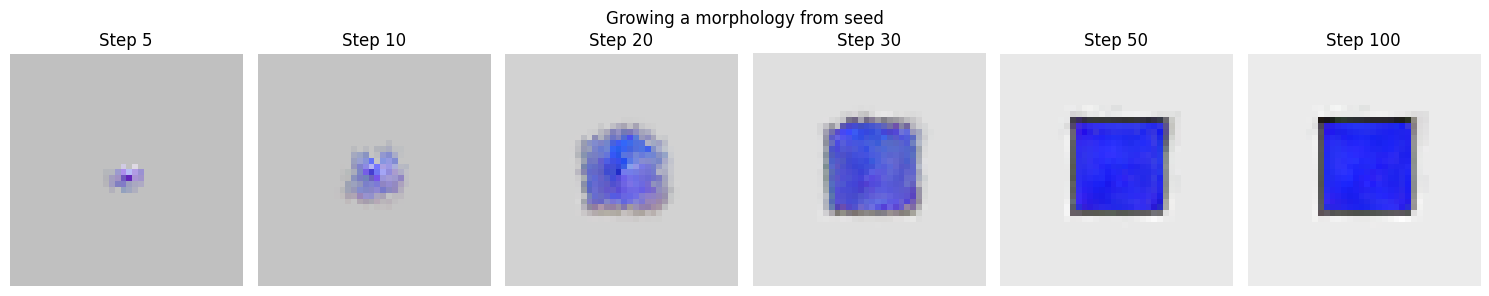

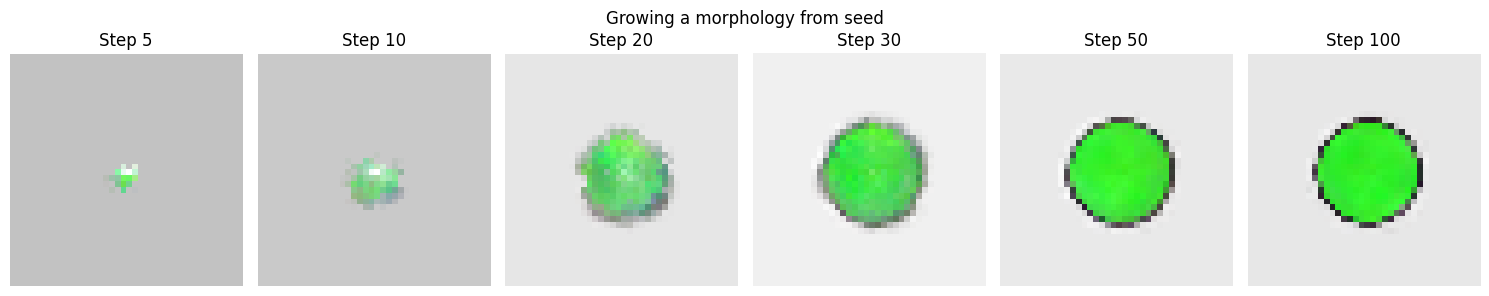

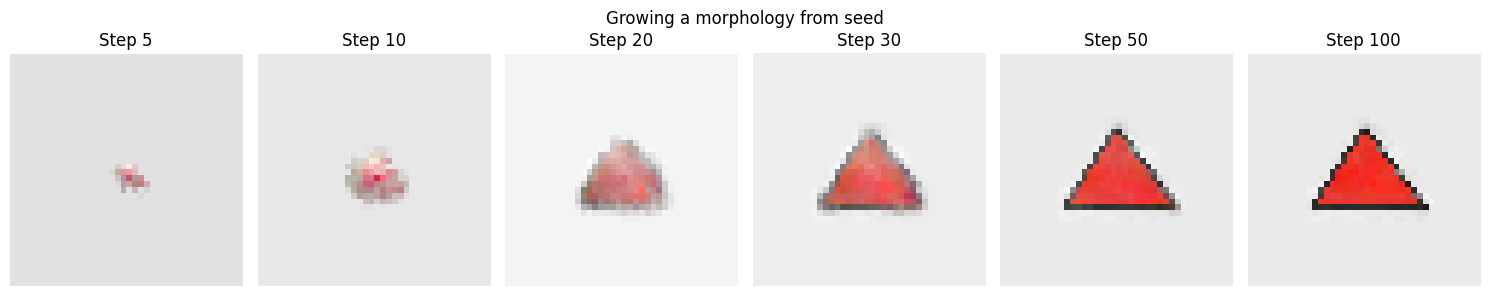

In [ ]:

## Growing the morphology
def visualize_growth(nca, seed, steps_to_show=[5, 10, 20, 30, 50, 100]):
    x = seed.clone()
    fig, axes = plt.subplots(1, len(steps_to_show), figsize=(15, 3))
    fig.suptitle("Growing a morphology from seed")

    current_step = 0
    with torch.no_grad():
        for i, target_step in enumerate(steps_to_show):
            steps_needed = target_step - current_step
            for _ in range(steps_needed):
                x = nca(x)
            current_step = target_step

            # Show RGB channels
            img = x[0, :4].permute(1, 2, 0).cpu().numpy()
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            axes[i].imshow(img)
            axes[i].set_title(f"Step {target_step}")
            axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Call it with a fresh seed
visualize_growth(nca, seeds[0].unsqueeze(0).to(x.device))
visualize_growth(nca, seeds[1].unsqueeze(0).to(x.device))
visualize_growth(nca, seeds[2].unsqueeze(0).to(x.device))


In [ ]:
def visualize_energy_during_growth(nca, make_seed_fn, n_shapes=3,
                                    total_steps=100, channels=4, device=DEVICE):
    """
    Tracks energy E(s) = -0.5 * ||s||^2 as each morphology grows from a seed.
    make_seed_fn(shape_idx) should return a fresh seed tensor for that shape.
    """
    shape_names = {0: "Square", 1: "Circle", 2: "Triangle"}
    colors      = {0: "blue",   1: "limegreen", 2: "red"}

    energies_per_shape = {i: [] for i in range(n_shapes)}
    steps = np.arange(0, total_steps)

    with torch.no_grad():
        for shape_idx in range(n_shapes):
            # Fresh seed for each shape, weights on zero
            x = make_seed_fn(shape_idx).to(device)

            for t in steps:
                x = nca(x)
                e = -0.5 * torch.sum(x[:, :channels, ...].pow(2)).item()
                energies_per_shape[shape_idx].append(e)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle("Energy Evolution During Morphological Growth", fontsize=13)



    #  early steps only
    early = 30
    ax1 = axes[0]
    for i in range(n_shapes):
        ax1.plot(steps[:early], energies_per_shape[i][:early],
                 label=f"Valley {i+1}: {shape_names[i]}",
                 color=colors[i], linewidth=2)
        # Mark where energy stabilizes (first time derivative < threshold)
        diffs = np.abs(np.diff(energies_per_shape[i][:early]))
        stable_idx = next((j for j, d in enumerate(diffs) if d < 1.0), None)
        if stable_idx:
            ax1.axvline(x=stable_idx, color=colors[i],
                       linestyle='--', alpha=0.4)
    ax1.set_title("Early Steps (Growth Phase)")
    ax1.set_xlabel("NCA Update Steps (t)")
    ax1.set_ylabel("Energy Score E(s)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()


    #  full growth window
    ax2 = axes[1]
    for i in range(n_shapes):
        ax2.plot(steps, energies_per_shape[i],
                 label=f"Valley {i+1}: {shape_names[i]}",
                 color=colors[i], linewidth=2)
    ax2.set_title("Full Growth Window")
    ax2.set_xlabel("NCA Update Steps (t)")
    ax2.set_ylabel("Energy Score E(s)")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return energies_per_shape

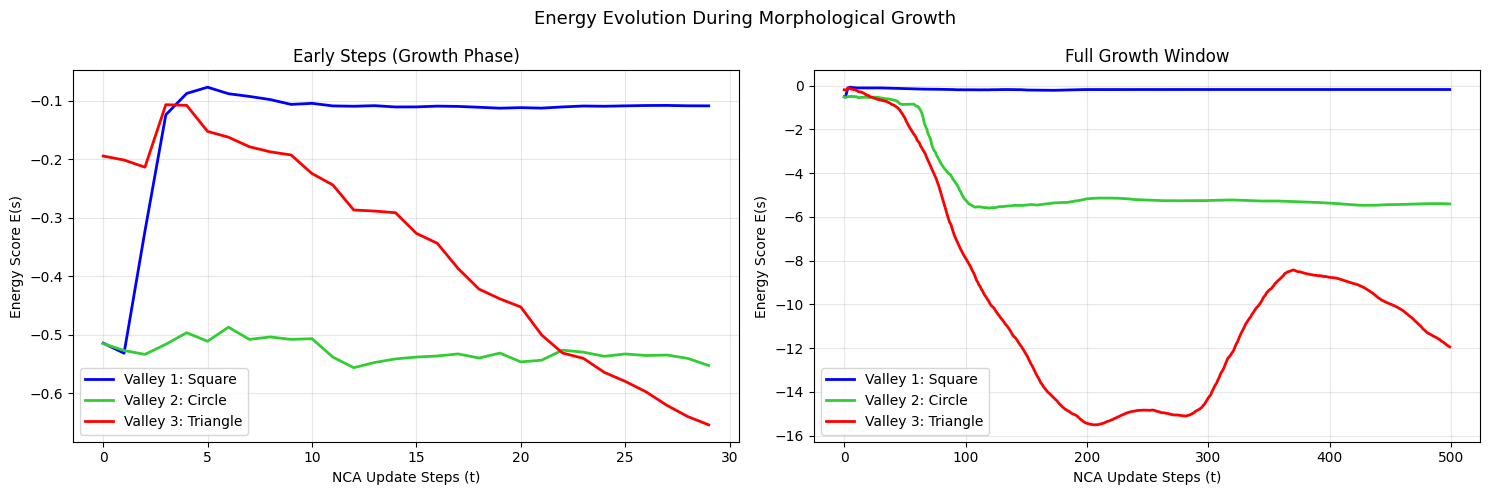

In [ ]:
def make_fresh_seed(shape_idx):
    """
    Returns a fresh seed tensor with the gene encoding for shape_idx.
    Adjust to match how your seeds/pools are structured.
    """
    # Create an empty grid
    seed = torch.zeros(1, nca.chn, HEIGHT, WIDTH, device=DEVICE)

    # Place a single alive seed cell in the center
    seed[:, 3, HEIGHT//2, WIDTH//2] = 1.0  # alpha channel

    # Set the gene encoding for this shape (binary, as in EngramNCA)
    gene_start = nca.chn - nca.channels  # index where gene channels start
    gene_encoding = torch.zeros(nca.gene_size, device=DEVICE)
    gene_encoding[shape_idx] = 1.0       # one-hot encoding
    seed[:, gene_start:gene_start + nca.gene_size, HEIGHT//2, WIDTH//2] = gene_encoding

    return seed

# Run it
energies = visualize_energy_during_growth(
    nca=nca,
    make_seed_fn=make_fresh_seed,
    n_shapes=3,
    total_steps=500,
    channels=4,
    device=DEVICE
)

In [ ]:
def apply_damage(x, damage_type='right_half', circle_radius=5):
    """
    Apply different damage patterns to a cell state.

    damage_type options:
        'right_half'   — remove right half (your original)
        'left_half'    — remove left half
        'center_circle'— remove a circle from the center
        'small_circle' — remove a small circle (severe local damage)
        'random'       — randomly zero out 50% of cells
        'cross'        — remove a cross through the center
    """
    x = x.clone()
    _, _, H, W = x.shape
    cy, cx = H // 2, W // 2  # center coordinates

    if damage_type == 'right_half':
        x[:, :, :, W//2:] = 0

    elif damage_type == 'left_half':
        x[:, :, :, :W//2] = 0

    elif damage_type == 'center_circle':
        # Remove a large circle from center
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) <= circle_radius**2
        x[:, :, mask] = 0

    elif damage_type == 'small_circle':
        # Severe: remove a tiny circle — forces regeneration from very little
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) > circle_radius**2
        x[:, :, mask] = 0  # keep ONLY the small circle, destroy everything else

    elif damage_type == 'random':
        noise = torch.rand(1, 1, H, W, device=x.device) > 0.5
        x = x * noise.float()

    elif damage_type == 'cross':
        thickness = max(1, H // 10)
        x[:, :, cy - thickness:cy + thickness, :] = 0  # horizontal bar
        x[:, :, :, cx - thickness:cx + thickness] = 0  # vertical bar

    return x

In [ ]:
## Damage experiments

def visualize_regeneration(nca, seed, shape_idx, base, damage,
                            channels=4, steps=200, device=DEVICE):

    if callable(seed):
        x = seed(shape_idx).to(device)
    else:
        x = seed.clone().to(device)

    # Damage: remove right half
    x = apply_damage(x, damage)

    frames        = [x[0, :4].permute(1, 2, 0).cpu().clip(0, 1).numpy()]
    loss_recovery   = []
    energy_recovery = []
    capture_steps   = [25, 50, 100, 150, 199]

    with torch.no_grad():
        for t in range(steps):
            x = nca(x)

            l = (base[0:1] - x[:, :4]).pow(2).mean().item()
            e = -0.5 * torch.sum(x[:, :channels].pow(2)).item()

            loss_recovery.append(l)
            energy_recovery.append(e)

            if t in capture_steps:
                frames.append(
                    x[0, :4].permute(1, 2, 0).cpu().clip(0, 1).numpy()
                )

    # ── Figure: two rows ────────────────────────────────────────────────
    fig = plt.figure(figsize=(20, 9))
    fig.suptitle(f"Regeneration after damage — Shape {shape_idx}", fontsize=13)

    # Row 1: visual frames
    titles = ['damaged'] + [f't={t}' for t in capture_steps]
    for i, (frame, title) in enumerate(zip(frames, titles)):
        ax = fig.add_subplot(2, len(frames), i + 1)
        ax.imshow(frame)
        ax.set_title(title)
        ax.axis('off')

    # Row 2: loss + energy recovery curves
    ax_loss = fig.add_subplot(2, 2, 3)
    ax_loss.plot(loss_recovery, color='blue', linewidth=1.5)
    ax_loss.set_title("Reconstruction Loss During Recovery")
    ax_loss.set_xlabel("NCA Steps")
    ax_loss.set_ylabel("MSE Loss")
    ax_loss.grid(True, alpha=0.3)
    # Mark capture steps
    for t in capture_steps:
        ax_loss.axvline(x=t, color='gray', linestyle='--', alpha=0.4)

    ax_energy = fig.add_subplot(2, 2, 4)
    ax_energy.plot(energy_recovery, color='red', linewidth=1.5)
    ax_energy.set_title("Energy Recovery E(s)")
    ax_energy.set_xlabel("NCA Steps")
    ax_energy.set_ylabel("Energy Score E(s)")
    ax_energy.grid(True, alpha=0.3)
    for t in capture_steps:
        ax_energy.axvline(x=t, color='gray', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

    return loss_recovery, energy_recovery



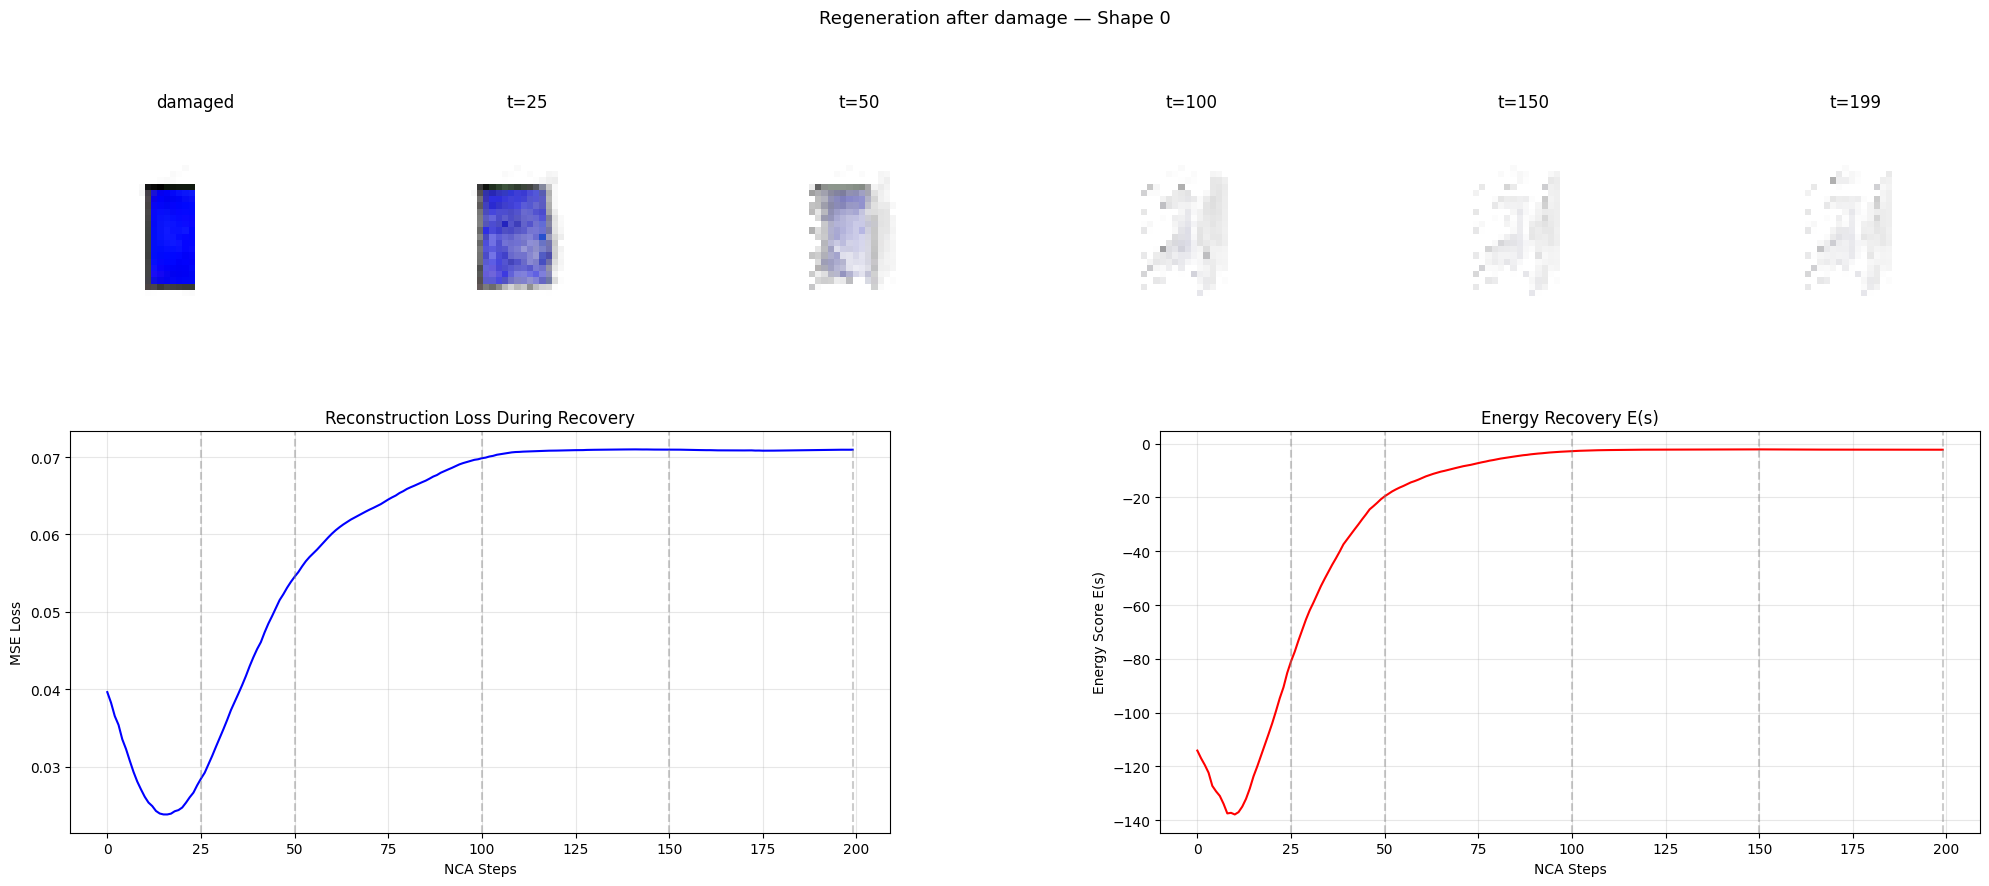

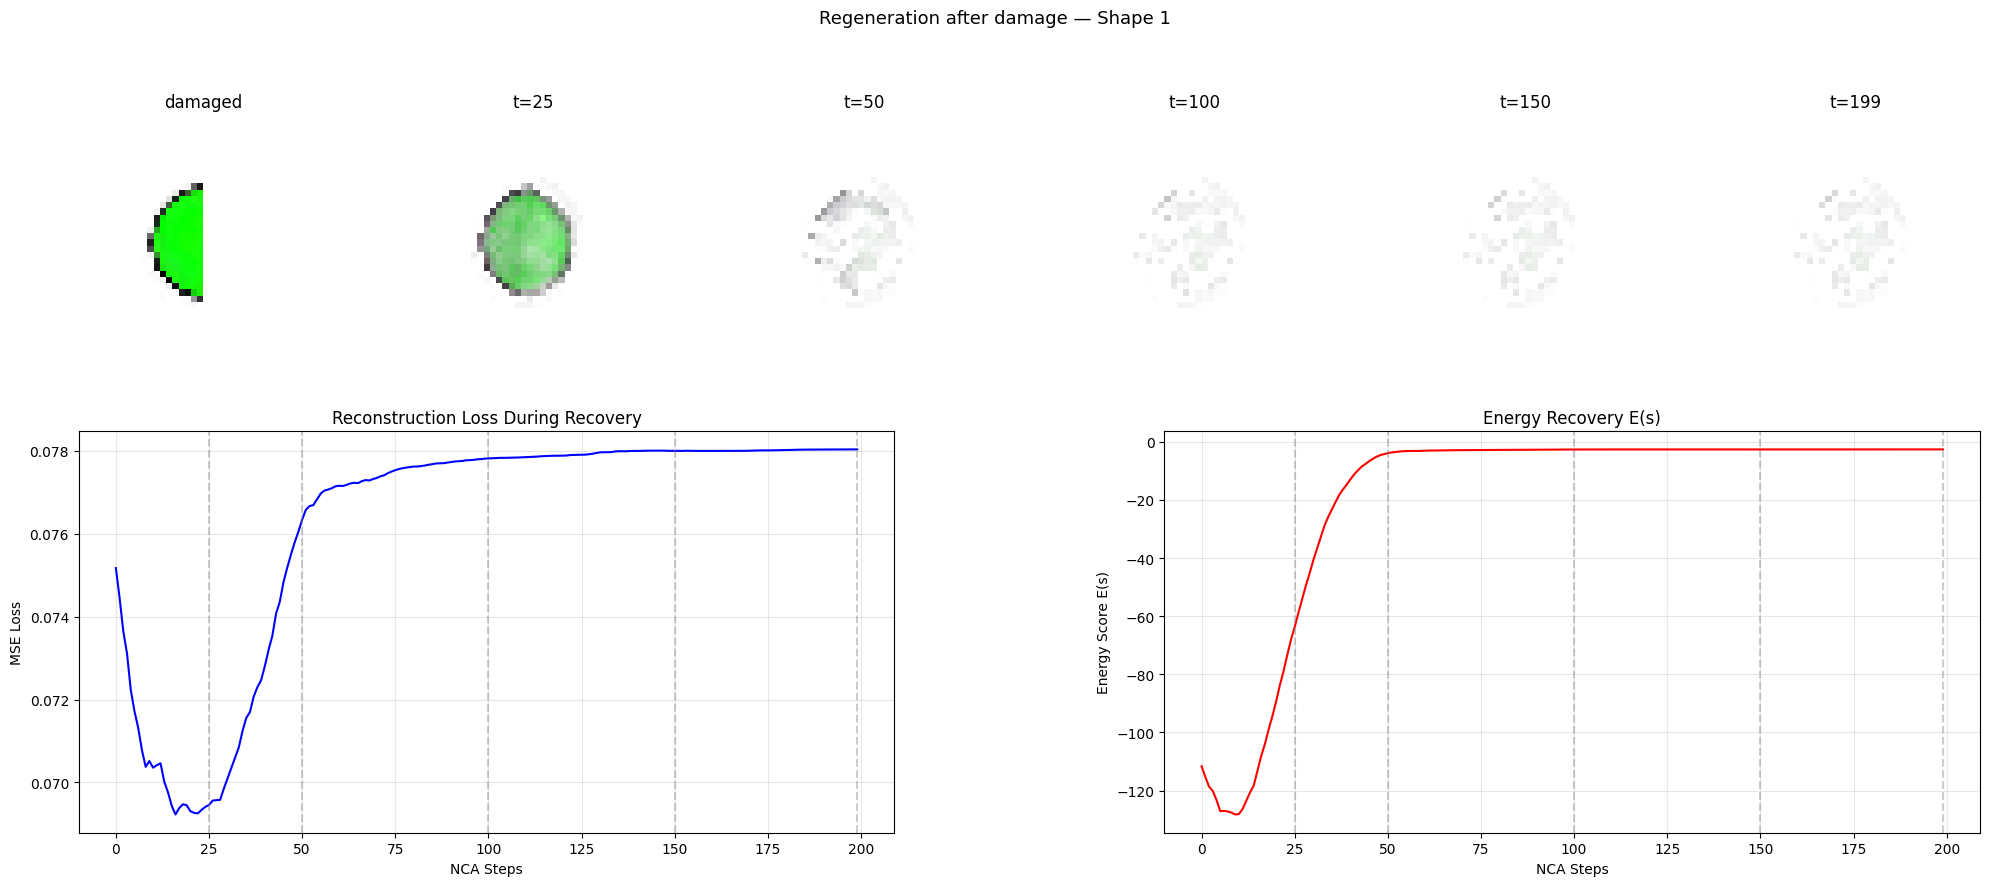

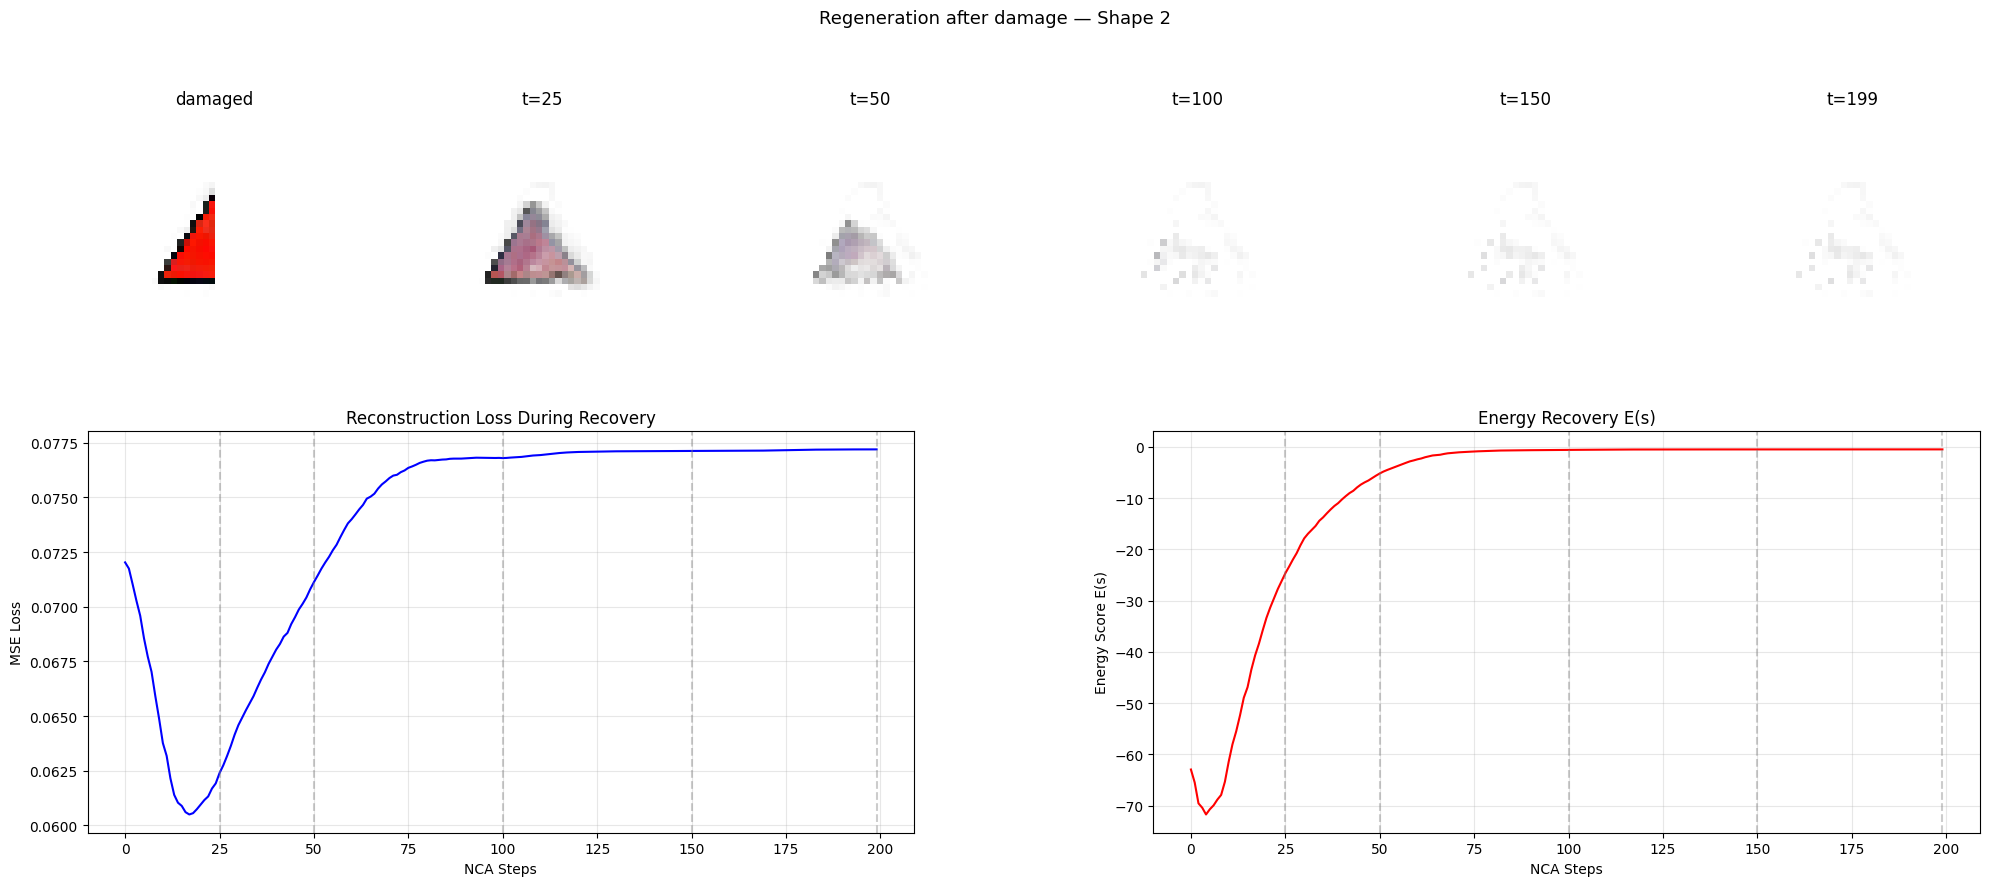

In [ ]:
for shape_idx in range(3):
    visualize_regeneration(nca, pools[shape_idx][0:1].to(DEVICE), shape_idx, base, "right_half" )

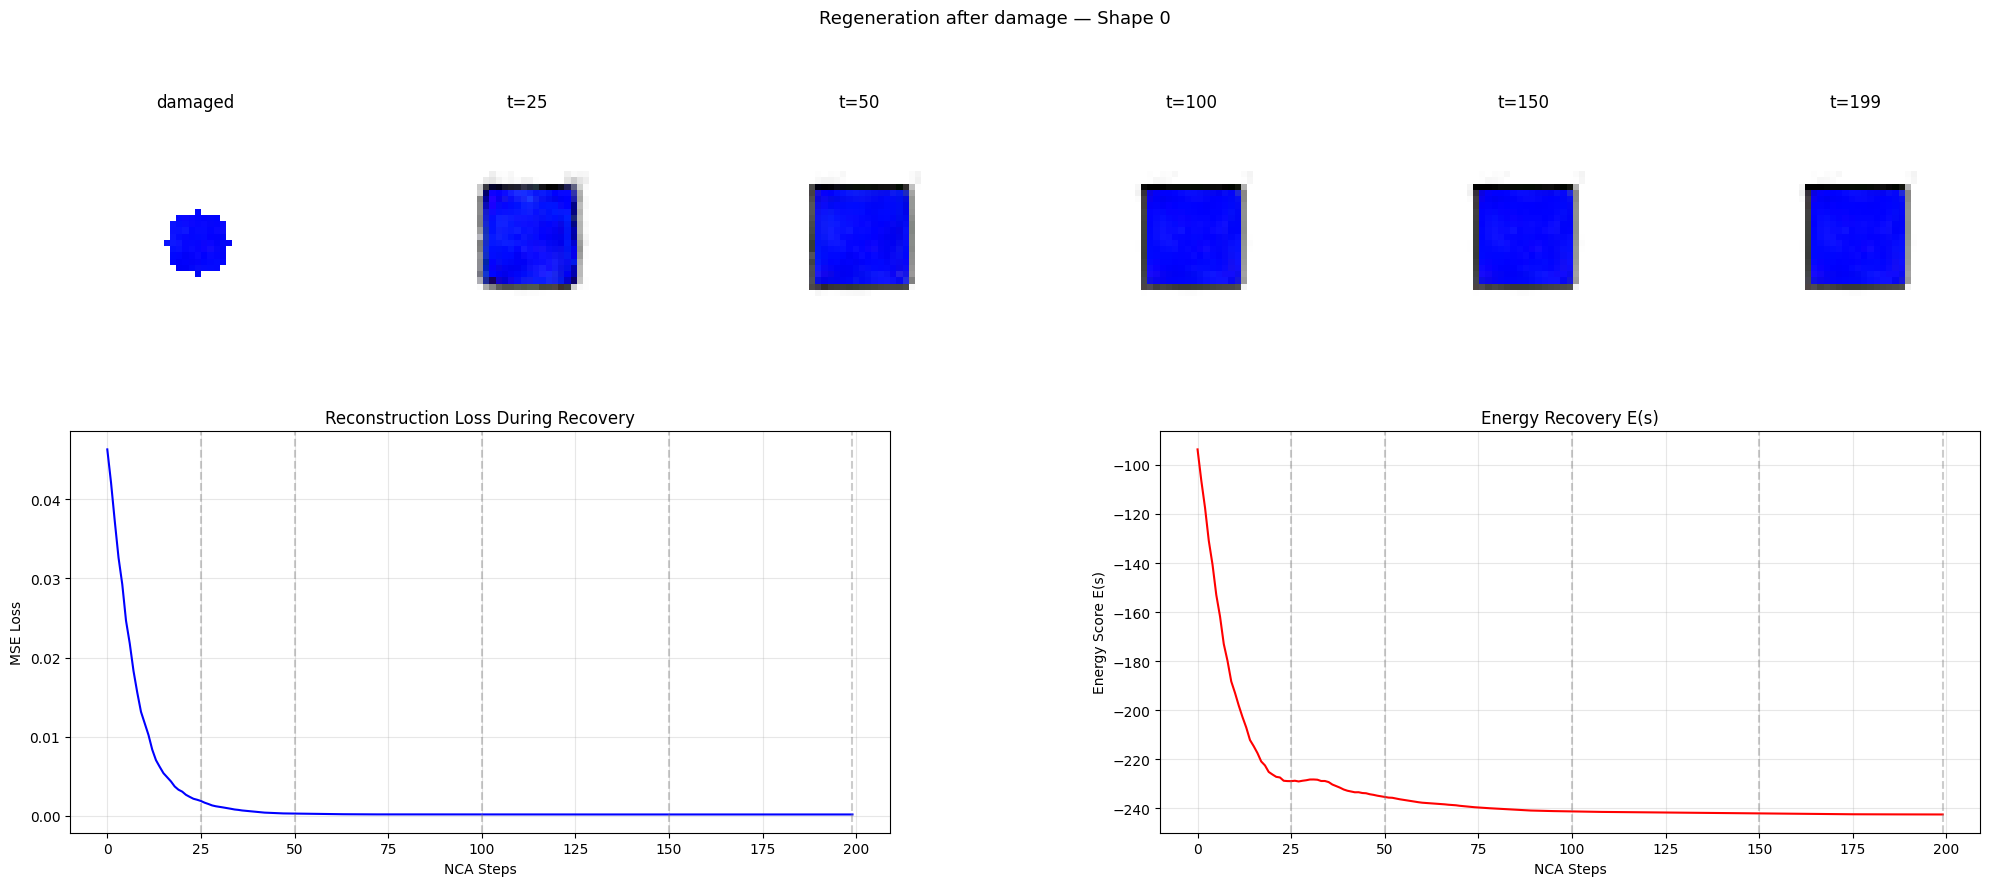

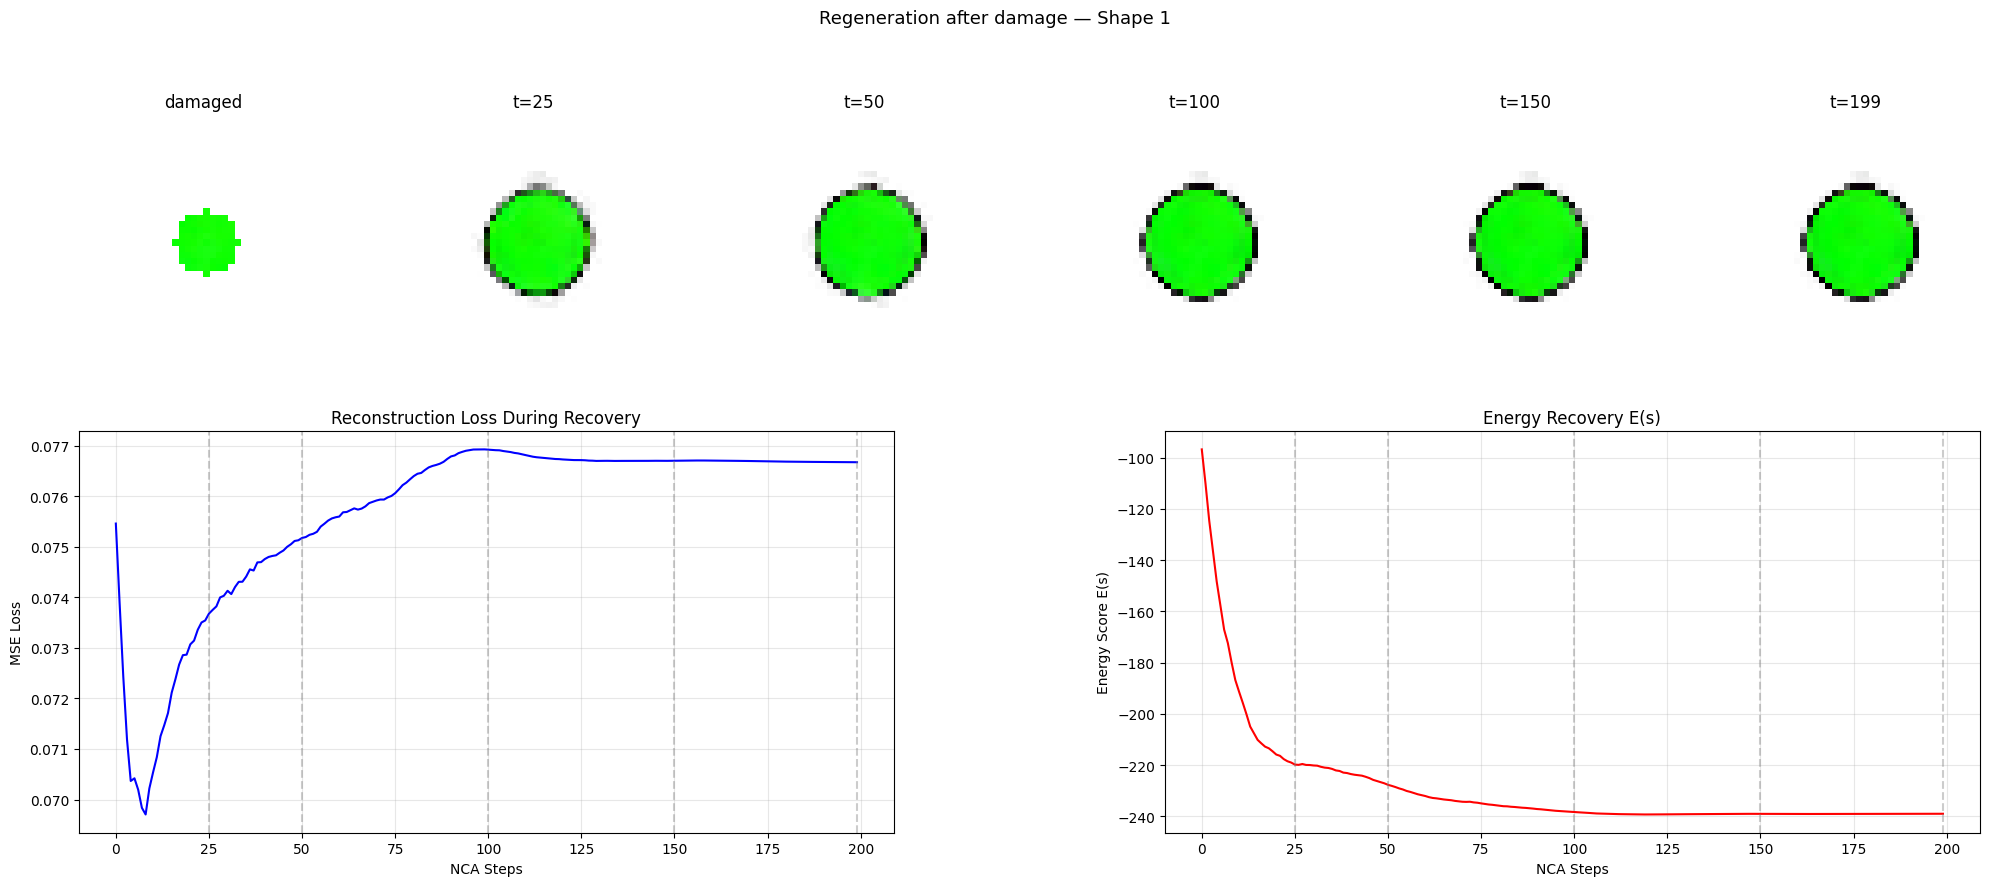

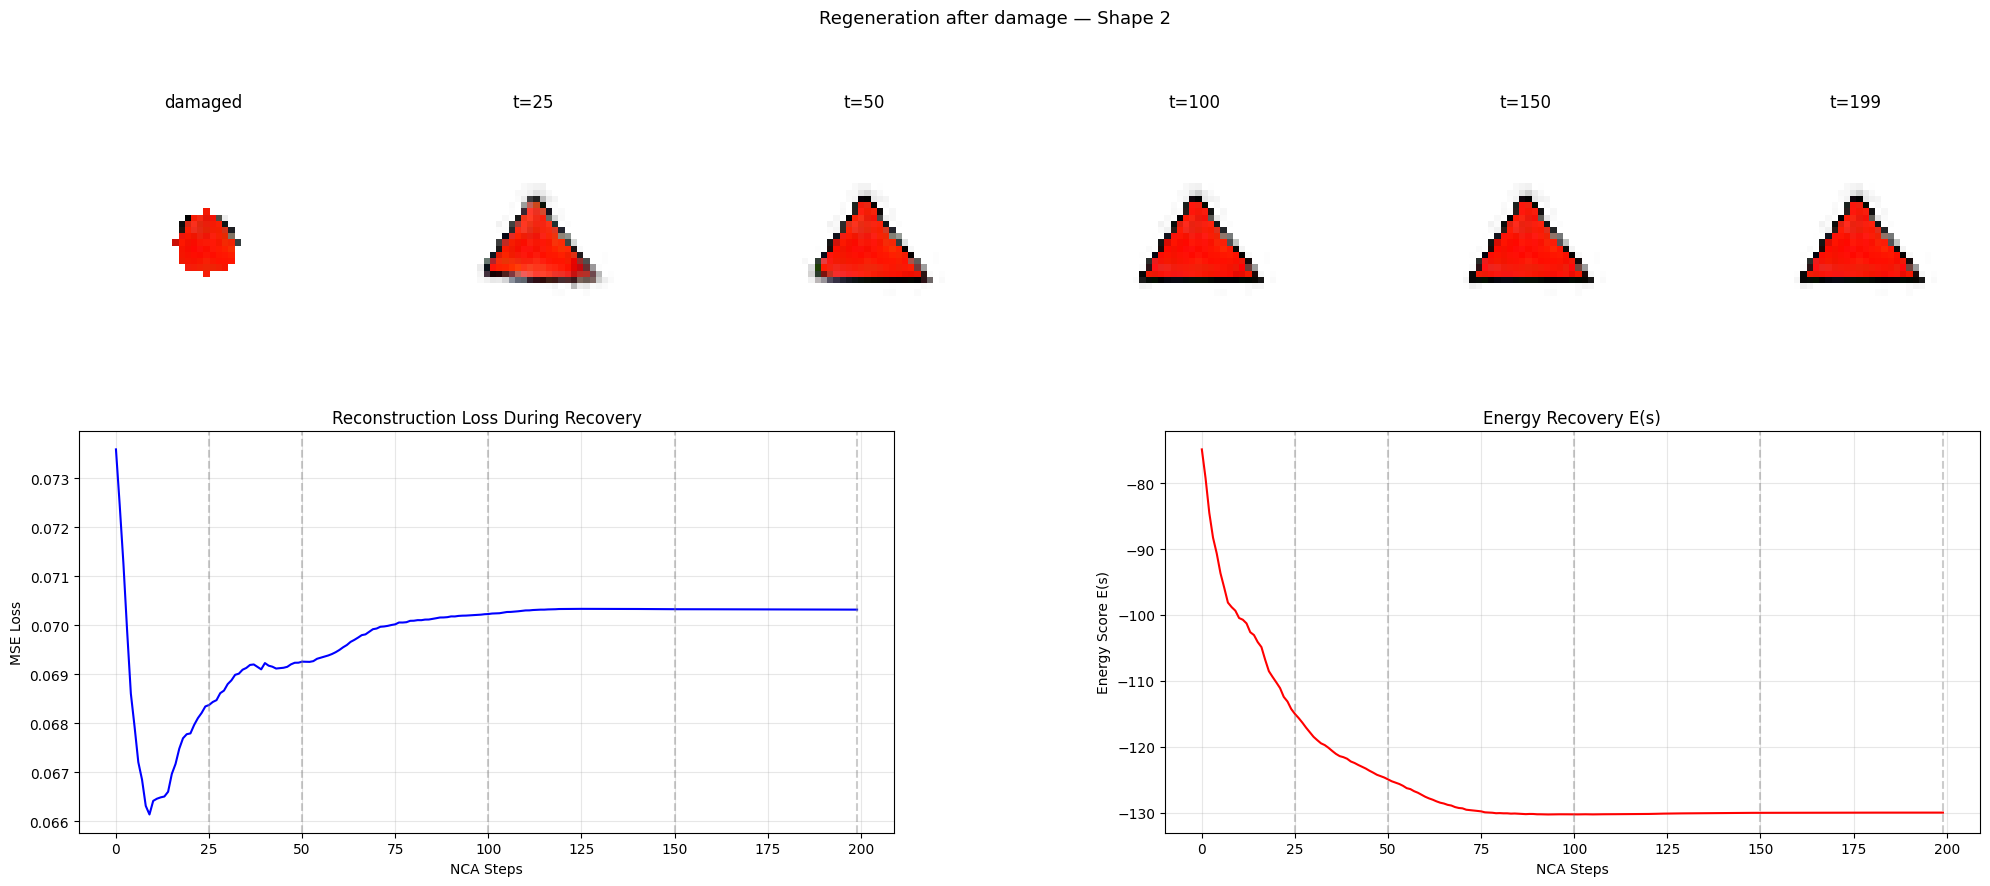

In [ ]:
for shape_idx in range(3):
    visualize_regeneration(nca, pools[shape_idx][0:1].to(DEVICE), shape_idx, base, "small_circle" )

In [ ]:
def get_state_at_step(nca, seed_fn, shape_idx, target_step, device=DEVICE):
    """Run NCA from seed for target_step steps and return that state."""
    x = seed_fn(shape_idx).to(device)
    with torch.no_grad():
        for _ in range(target_step):
            x = nca(x)
    return x

# Example: get square at step 30
x_at_step30 = get_state_at_step(nca, make_fresh_seed, shape_idx=0, target_step=30)

visualize_regeneration(nca, x_at_step30, shape_idx=0, base, 'random')

SyntaxError: positional argument follows keyword argument (2459469298.py, line 12)

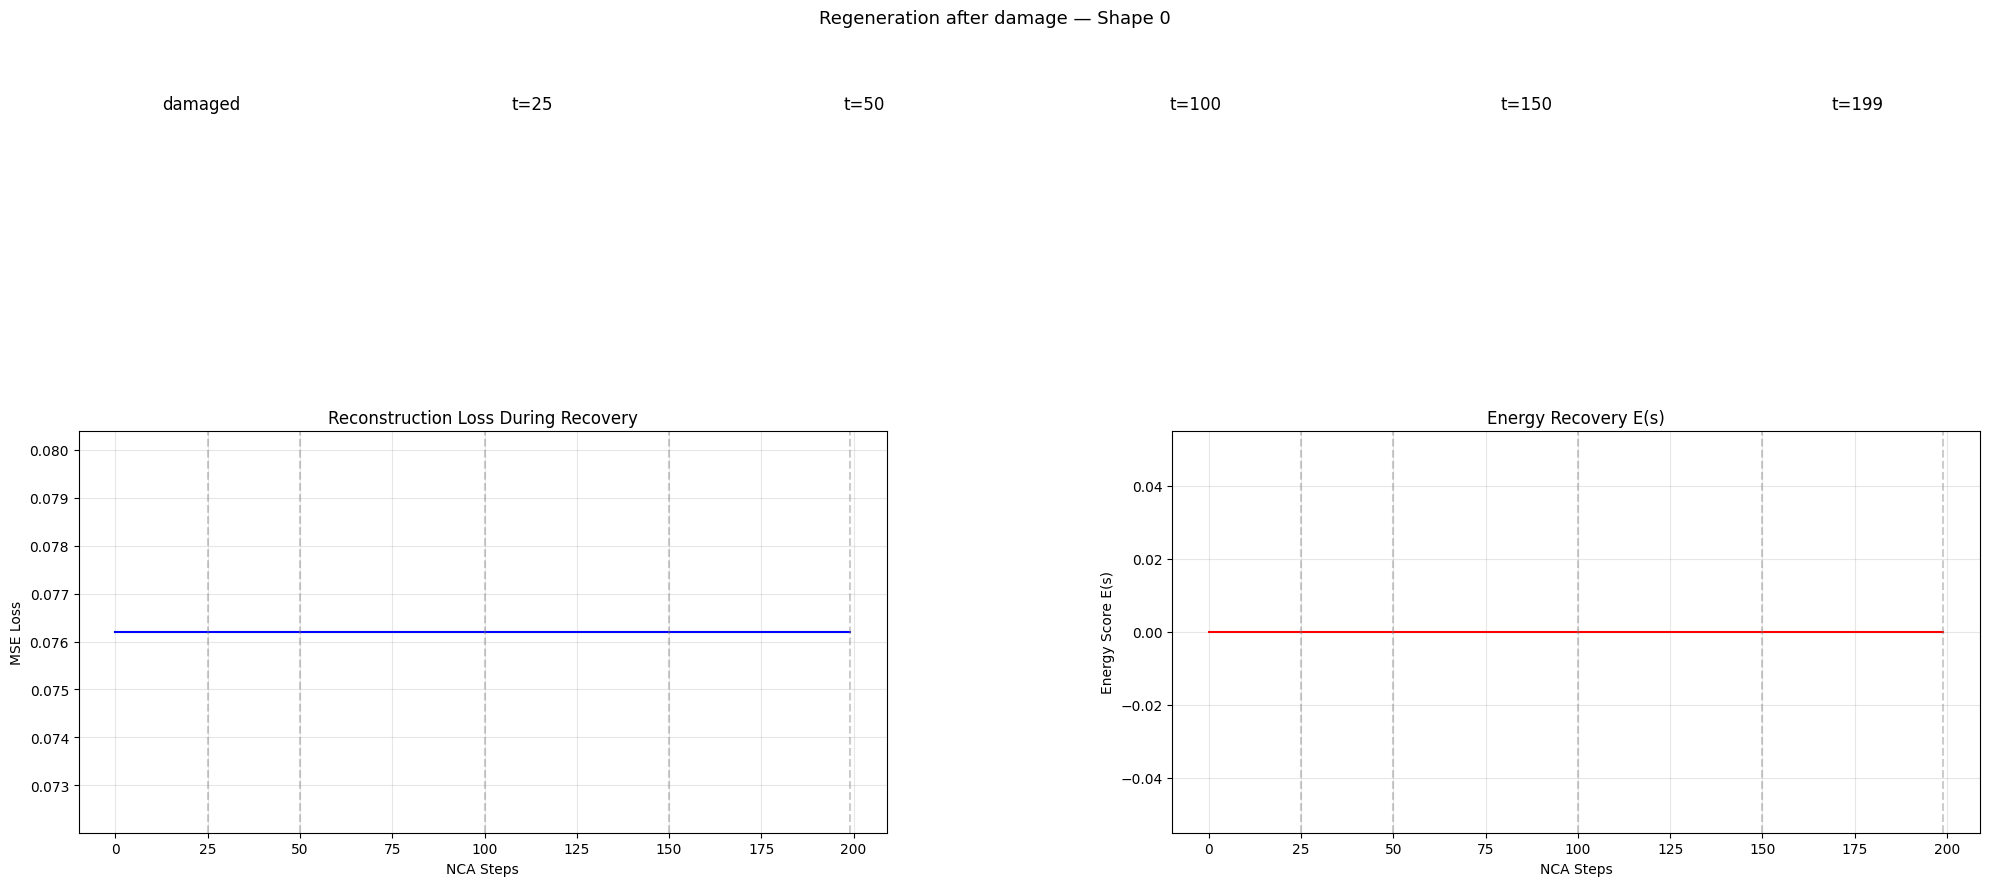

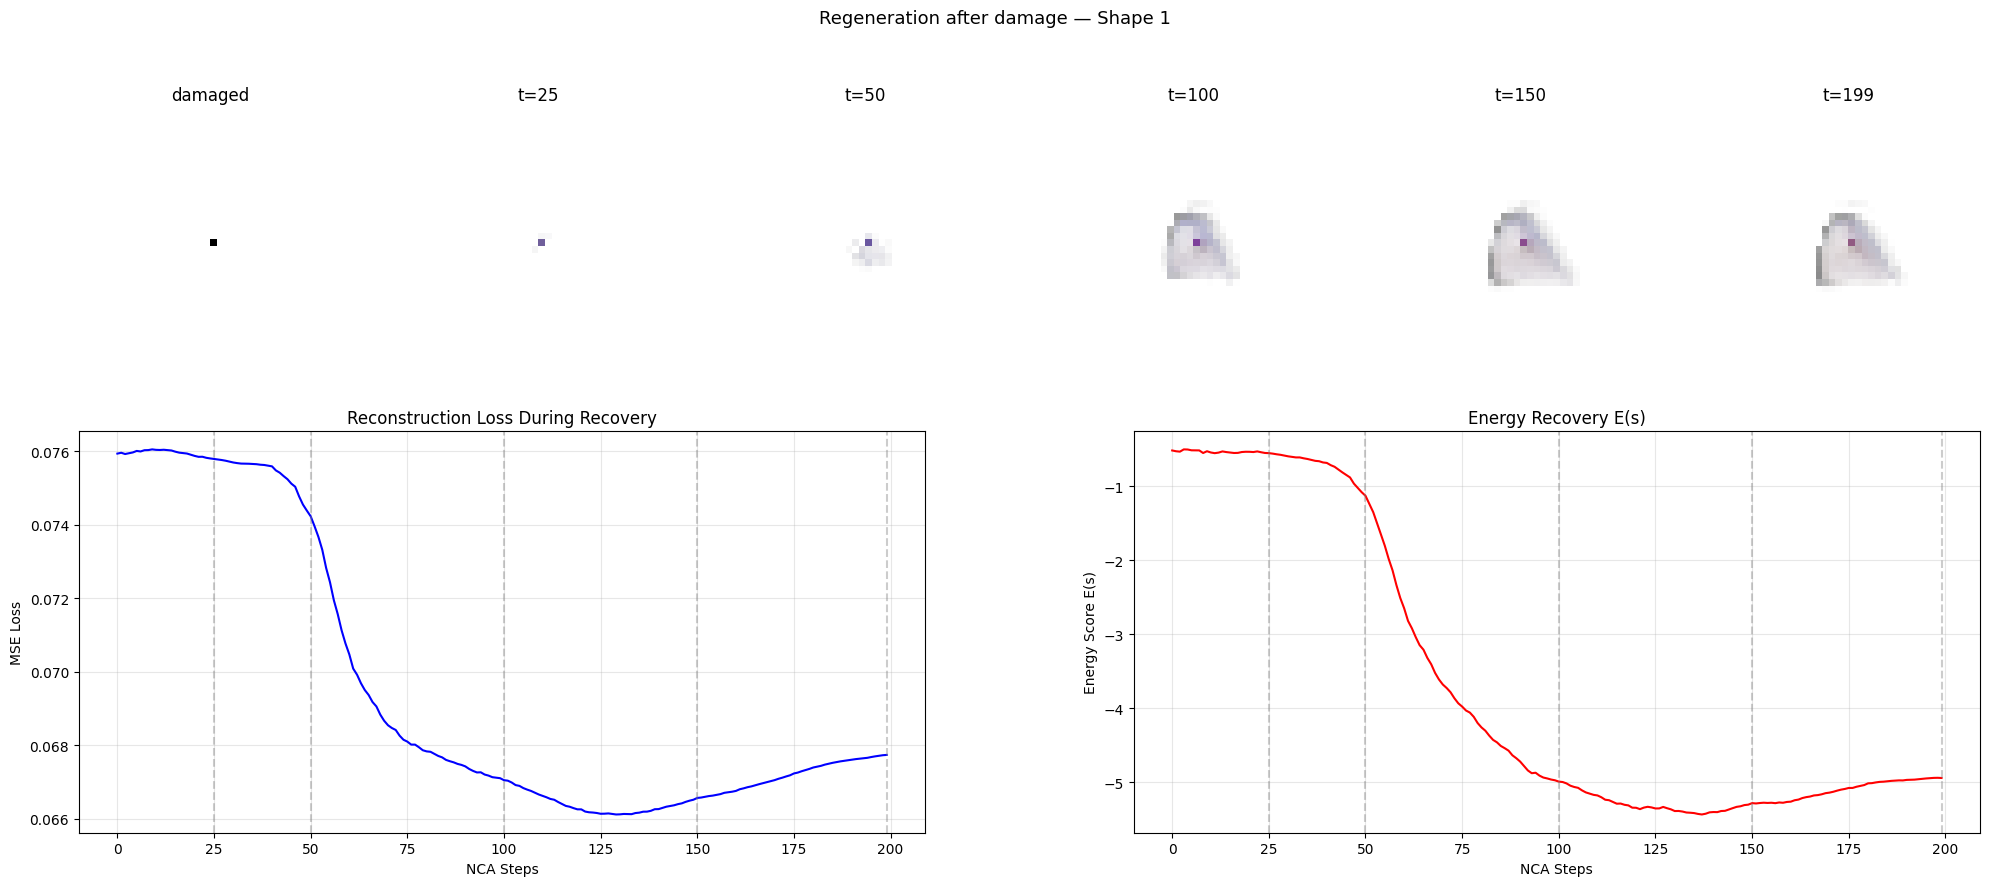

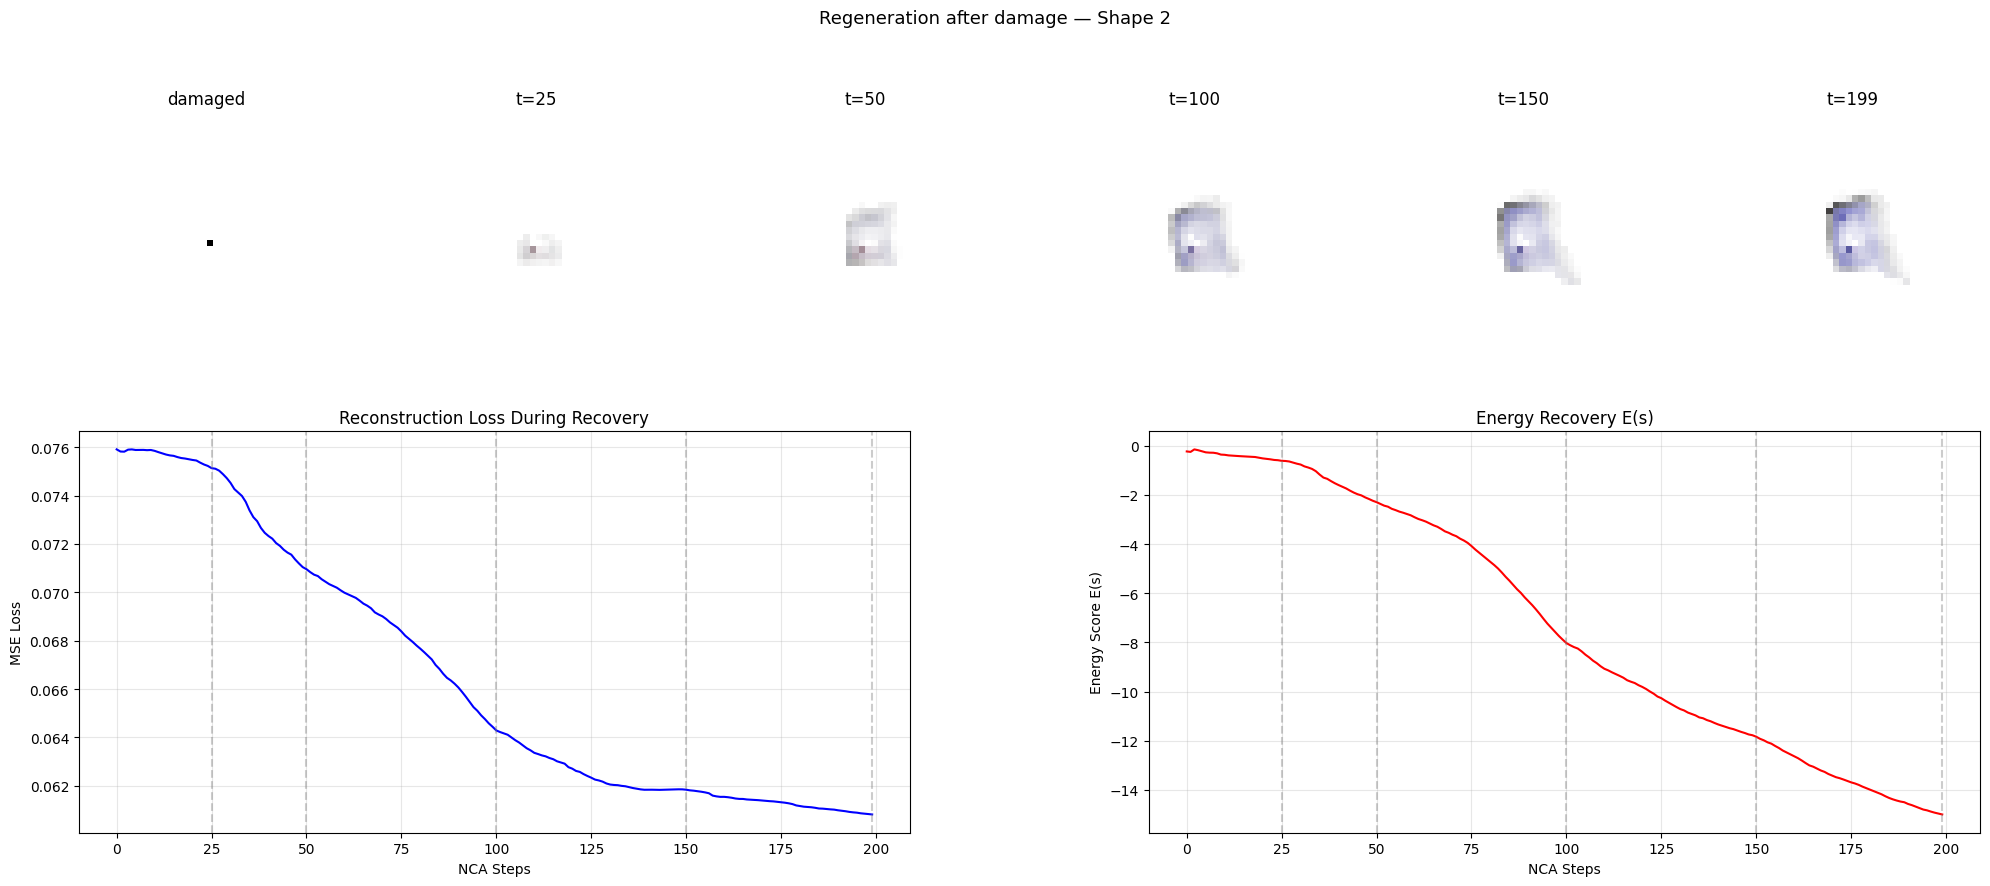

In [ ]:
# Run for all three shapes
for shape_idx in range(3):
    visualize_regeneration(nca, make_fresh_seed, shape_idx, base, 'random')

In [ ]:
del optim
torch.cuda.empty_cache()